
# ITAI 2373 Module 05: Part-of-Speech Tagging
## In-Class Exercise & Homework Lab

Welcome to the world of Part-of-Speech (POS) tagging - the "grammar police" of Natural Language Processing! 🚔📝

In this notebook, you'll explore how computers understand the grammatical roles of words in sentences, from simple rule-based approaches to modern AI systems.

### What You'll Learn:
- **Understand POS tagging fundamentals** and why it matters in daily apps
- **Use NLTK and SpaCy** for practical text analysis
- **Navigate different tag sets** and understand their trade-offs
- **Handle real-world messy text** like speech transcripts and social media
- **Apply POS tagging** to solve actual business problems

### Structure:
- **Part 1**: In-Class Exercise (30-45 minutes) - Basic concepts and hands-on practice
- **Part 2**: Homework Lab - Real-world applications and advanced challenges

---

*💡 **Pro Tip**: POS tagging is everywhere! It helps search engines understand "Apple stock" vs "apple pie", helps Siri understand your commands, and powers autocorrect on your phone.*



## 🛠️ Setup and Installation

Let's get our tools ready! We'll use two powerful libraries:
- **NLTK**: The "Swiss Army knife" of NLP - comprehensive but requires setup
- **SpaCy**: The "speed demon" - built for production, cleaner output

Run the cells below to install and set up everything we need.


In [ ]:

# Install required libraries (run this first!)
!pip install nltk spacy matplotlib seaborn pandas
!python -m spacy download en_core_web_sm

print("✅ Installation complete!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 81.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Installation complete!


In [ ]:
# Import all the libraries we'll need
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (this might take a moment)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('universal_tagset')
nltk.download('punkt_tab') # Added to download the missing resource
nltk.download('averaged_perceptron_tagger_eng') # Added to download the missing resource for pos_tag

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

print("🎉 All libraries loaded successfully!")
print("📚 NLTK version:", nltk.__version__)
print("🚀 SpaCy version:", spacy.__version__)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


🎉 All libraries loaded successfully!
📚 NLTK version: 3.9.1
🚀 SpaCy version: 3.8.16



---
# 🎯 PART 1: IN-CLASS EXERCISE (30-45 minutes)

Welcome to the hands-on portion! We'll start with the basics and build up your understanding step by step.

## Learning Goals for Part 1:
1. Understand what POS tagging does
2. Use NLTK and SpaCy for basic tagging
3. Interpret and compare different tag outputs
4. Explore word ambiguity with real examples
5. Compare different tagging approaches



## 🔍 Activity 1: Your First POS Tags (10 minutes)

Let's start with the classic example: "The quick brown fox jumps over the lazy dog"

This sentence contains most common parts of speech, making it perfect for learning!


In [ ]:
sentence = "The quick brown fox jumps over the lazy dog"

# TODO: Use NLTK to tokenize and tag the sentence
# Hint: Use nltk.word_tokenize() and nltk.pos_tag()
tokens = nltk.word_tokenize(sentence)
pos_tags = nltk.pos_tag(tokens)

print("Original sentence:", sentence)
print("\nTokens:", tokens)
print("\nPOS Tags:")
for word, tag in pos_tags:
    print(f"  {word:8} -> {tag}")

Original sentence: The quick brown fox jumps over the lazy dog

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

POS Tags:
  The      -> DT
  quick    -> JJ
  brown    -> NN
  fox      -> NN
  jumps    -> VBZ
  over     -> IN
  the      -> DT
  lazy     -> JJ
  dog      -> NN



### 🤔 Quick Questions:
1. What does 'DT' mean? What about 'JJ'?
**Ans:
DT (Determiner) is words that introduce a noun and specify its reference, such as articles (the, a, an), demonstratives (this, that), or quantifiers.
JJ (Adjective) is words that modify, describe, or qualify a noun or pronoun (e.g., quick, brown, lazy).

2. Why do you think 'brown' and 'lazy' have the same tag?
**Ans:
'brown' and 'lazy' have the same tag because if a sentence like "The quick brown fox jumps over the lazy dog". This shows both brown and lazy act as adjectives (JJ). Their grammatical role is identical because they directly modify nouns (fox and dog, respectively) by describing their qualities.

3. Can you guess what 'VBZ' represents?
**Ans:
VBZ stands for Verb, 3rd person singular present. For example, the word "jumps" is a present tense action performed by a singular third person subject (the fox/it).

*Hint: Think about the grammatical role each word plays in the sentence!*



## 🚀 Activity 2: SpaCy vs NLTK Showdown (10 minutes)

Now let's see how SpaCy handles the same sentence. SpaCy uses cleaner, more intuitive tag names.


In [ ]:

# TODO: Process the same sentence with SpaCy
# Hint: Use nlp(sentence) and access .text and .pos_ attributes
doc = nlp(sentence)

print("SpaCy POS Tags:")
for token in doc:
    print(f"  {token.text:8} -> {token.pos_:6} ({token.tag_})")

print("\n" + "="*50)
print("COMPARISON:")
print("="*50)

# Let's compare side by side
nltk_tags = nltk.pos_tag(nltk.word_tokenize(sentence))
spacy_doc = nlp(sentence)

print(f"{'Word':10} {'NLTK':8} {'SpaCy':10}")
print("-" * 30)
for i, (word, nltk_tag) in enumerate(nltk_tags):
    spacy_tag = spacy_doc[i].pos_
    print(f"{word:10} {nltk_tag:8} {spacy_tag:10}")


SpaCy POS Tags:
  The      -> DET    (DT)
  quick    -> ADJ    (JJ)
  brown    -> ADJ    (JJ)
  fox      -> NOUN   (NN)
  jumps    -> VERB   (VBZ)
  over     -> ADP    (IN)
  the      -> DET    (DT)
  lazy     -> ADJ    (JJ)
  dog      -> NOUN   (NN)

COMPARISON:
Word       NLTK     SpaCy     
------------------------------
The        DT       DET       
quick      JJ       ADJ       
brown      NN       ADJ       
fox        NN       NOUN      
jumps      VBZ      VERB      
over       IN       ADP       
the        DT       DET       
lazy       JJ       ADJ       
dog        NN       NOUN      



### 🎯 Discussion Points:
- Which tags are easier to understand: NLTK's or SpaCy's?
**Ans: SpaCy’s tags are generally easier to understand at first glance. SpaCy uses coarse-grained Universal POS tags like ADJ, NOUN, VERB, DET which are intuitive and human readable that is alongside fine-gained tags.
- Do you notice any differences in how they tag the same words?
**Ans:
The difference in how they tage the same words are
Granularity vs. Simplicity is where the NLTK's default tags capture specific grammatical nuances. This is when distinguishing a 3rd person singular present verb that is from a base form verb. SpaCy abstracts these into high-level categories while still storing detailed morphological features under fine-grained attributes.
Handling Context & Ambiguity is where the SpaCy uses a statistical/neural model trained on context windows, making it slightly more adept out-of-the-box at handling ambiguous words or modern sentence structures than NLTK's traditional
- Which system would you prefer for a beginner? Why?
**Ans:
SpaCy is the preferred choice for beginners.
The reason for this are:
Clearer Output is where the SpaCy standard that labels map directly to fundamental parts of speech taught in basic grammar (Noun, Verb, Adjective), making results instantly interpretable without memorizing tagset codes.
Modern API is where SpaCy processes text into a single cohesive object. This will have you access token text, lemma, broad POS tags, and fine-grained tags seamlessly without running separate tokenization and tagging steps as in NLTK.



## 🎭 Activity 3: The Ambiguity Challenge (15 minutes)

Here's where things get interesting! Many words can be different parts of speech depending on context. Let's explore this with some tricky examples.


In [ ]:

# Ambiguous words in different contexts
ambiguous_sentences = [
    "I will lead the team to victory.",           # lead = verb
    "The lead pipe is heavy.",                    # lead = noun (metal)
    "She took the lead in the race.",            # lead = noun (position)
    "The bank approved my loan.",                # bank = noun (financial)
    "We sat by the river bank.",                 # bank = noun (shore)
    "I bank with Chase.",                        # bank = verb
]

print("🎭 AMBIGUITY EXPLORATION")
print("=" * 40)

for sentence in ambiguous_sentences:
    print(f"\nSentence: {sentence}")

    # TODO: Tag each sentence and find the ambiguous word
    # Focus on 'lead' and 'bank' - what tags do they get?
    tokens = nltk.word_tokenize(sentence)
    tags = nltk.pos_tag(tokens)

    # Find and highlight the key word
    for word, tag in tags:
        if word.lower() in ['lead', 'bank']:
            print(f"  🎯 '{word}' is tagged as: {tag}")


🎭 AMBIGUITY EXPLORATION

Sentence: I will lead the team to victory.
  🎯 'lead' is tagged as: VB

Sentence: The lead pipe is heavy.
  🎯 'lead' is tagged as: NN

Sentence: She took the lead in the race.
  🎯 'lead' is tagged as: NN

Sentence: The bank approved my loan.
  🎯 'bank' is tagged as: NN

Sentence: We sat by the river bank.
  🎯 'bank' is tagged as: NN

Sentence: I bank with Chase.
  🎯 'bank' is tagged as: NN



### 🧠 Think About It:
1. How does the computer know the difference between "lead" (metal) and "lead" (guide)?
**Ans:
The computer know the difference between "lead" (metal) and "lead" (guide) is
Traditional statistical POS taggers and neural models don't actually "know" real-world definitions. Instead, they use contextual pattern recognition:
N-gram / Neighbor Context where the tagger looks at the sequence of words immediately surrounding "lead".
Part-of-Speech Assignments is where the word lead from the sentence "The lead pipe.." is followed directly by a noun ("pipe") and preceded by a determiner ("The"), signaling that it is acting as a noun/modifier rather than an action verb. In "I will lead the team...", "lead" follows a modal verb ("will"), which statistically strongly predicts a base-form verb
Statistical Probabilities is where the model relies on transition probabilities trained on massive annotated datasets (like the Penn Treebank)

2. What clues in the sentence help determine the correct part of speech?
**Ans:
The clues in the sentence that help determine the correct part of speech are
Syntactic Position & Neighboring Parts of Speech
- Preceding Auxiliaries/Modals is when words like can, will, should, to indicate the following word is likely a verb ("to lead").
- Determiners/Articles is when words like a, an, the, this indicate a noun phrase is beginning ("the lead").
Structural Role (Subject/Verb/Object) is where the overall sentence structure helps isolate where the main action (verb) vs. entity (noun) resides.
Morphological Indicators is where the suffixes or nearby inflectional markers (e.g., -ing, -ed, -s) around surrounding words clarify the clause's tense and roles.


3. Can you think of other words that change meaning based on context?
**Ans:
Other words that change the meaning based on context are

Bass:
Noun (Fish): "He caught a bass in the lake."
Noun/Adj (Sound/Instrument): "Turn up the bass in the speaker."

Record:
Verb: "Please record the meeting." (Stress on second syllable: re-CORD)
Noun: "She set a world record." (Stress on first syllable: RE-cord)

Object:
Noun: "What is that shiny object on the floor?"
Verb: "I object to that decision!"

Contract:
Noun: "Sign the employment contract."
Verb: "Metals contract as they cool."

Desert:
Noun: "The Sahara is a vast desert."
Verb: "He would never desert his teammates."


**Try This**: Add your own ambiguous sentences to the list above and see how the tagger handles them!



## 📊 Activity 4: Tag Set Showdown (10 minutes)

NLTK can use different tag sets. Let's compare the detailed Penn Treebank tags (~45 tags) with the simpler Universal Dependencies tags (~17 tags).


In [ ]:

# Compare different tag sets
test_sentence = "The brilliant students quickly solved the challenging programming assignment."

# Tokenize the sentence once
tokens = nltk.word_tokenize(test_sentence)

# TODO: Get tags using both Penn Treebank and Universal tagsets
# Hint: Use tagset='universal' parameter for universal tags
penn_tags = nltk.pos_tag(tokens)
universal_tags = nltk.pos_tag(tokens, tagset='universal')

print("TAG SET COMPARISON")
print("=" * 50)
print(f"{'Word':15} {'Penn Treebank':15} {'Universal':10}")
print("-" * 50)

# TODO: Print comparison table
# Hint: Zip the two tag lists together
for (word, penn_tag), (_, univ_tag) in zip(penn_tags, universal_tags):
    print(f"{word:15} {penn_tag:15} {univ_tag:10}")

# Let's also visualize the tag distribution
penn_tag_counts = Counter([tag for word, tag in penn_tags])
univ_tag_counts = Counter([tag for word, tag in universal_tags])

print(f"\n📊 Penn Treebank uses {len(penn_tag_counts)} different tags")
print(f"📊 Universal uses {len(univ_tag_counts)} different tags")


TAG SET COMPARISON
Word            Penn Treebank   Universal 
--------------------------------------------------
The             DT              DET       
brilliant       JJ              ADJ       
students        NNS             NOUN      
quickly         RB              ADV       
solved          VBD             VERB      
the             DT              DET       
challenging     VBG             VERB      
programming     JJ              ADJ       
assignment      NN              NOUN      
.               .               .         

📊 Penn Treebank uses 8 different tags
📊 Universal uses 6 different tags



### 🤔 Reflection Questions:
1. Which tag set is more detailed? Which is simpler? Enter your answer below
**Ans:
The tag set that is more detailed is the Penn Treebank tagset. It uses approximately 45 fine-grained tags such as VBZ for third person singular present verbs, VBD for past tense verbs or NNS for plural nouns.
The simpler is the Universal Dependencies tagset is simpler. It collapses grammatical categories down to about 17 high-level tags such as VERB,NOUN and ADJ.
2. When might you want detailed tags vs. simple tags? Enter your answer below
**Ans:
Might want to use detailed tags vs. simple tags is:
Using Detailed Tags (Penn Treebank) is when performing deep linguistic analysis, syntactic parsing, sentiment analysis, text generation, or grammar checking where specific verb tenses, singular/plural distinctions, and mood matter.
Using Simple Tags (Universal Dependencies) is when working on cross-lingual tasks, high-speed data processing, broad topic classification, or when building baseline NLP models where general grammatical role matters more than fine-grained inflection.

3. If you were building a search engine, which would you choose? Why? Enter your answer below
**Ans:
I would choose Universal Dependencies (Simple Tags). The reason I choose this is because:
it has Efficiency & Speed where the search engines must index and query billions of tokens in real time; smaller tag sets reduce memory footprint and computational overhead.
Has Intent Matching where the Query parsing typically relies on identifying main entities (NOUN) and actions (VERB) to understand user intent rather than caring whether a verb is past tense or 3rd-person singular present.
Lastly, Multi-Language Normalization where the universal tags provide a standardized, consistent schema across different languages, making international search indexing much easier to maintain.

---



---
# 🎓 End of Part 1: In-Class Exercise

Great work! You've learned the fundamentals of POS tagging and gotten hands-on experience with both NLTK and SpaCy.

## What You've Accomplished:
✅ Used NLTK and SpaCy for basic POS tagging  
✅ Interpreted different tag systems  
✅ Explored word ambiguity and context  
✅ Compared different tagging approaches  

## 🏠 Ready for Part 2?
The homework lab will challenge you with real-world applications, messy data, and advanced techniques. You'll analyze customer service transcripts, handle informal language, and benchmark different taggers.

**Take a break, then dive into Part 2 when you're ready!**

---



# 🏠 PART 2: HOMEWORK LAB
## Real-World POS Tagging Challenges

Welcome to the advanced section! Here you'll tackle the messy, complex world of real text data. This is where POS tagging gets interesting (and challenging)!

## Learning Goals for Part 2:
1. Process real-world, messy text data
2. Handle speech transcripts and informal language
3. Analyze customer service scenarios
4. Benchmark and compare different taggers
5. Understand limitations and edge cases

## 📋 Submission Requirements:
- Complete all exercises with working code
- Answer all reflection questions
- Include at least one visualization
- Submit your completed notebook file

---



## 🌍 Lab Exercise 1: Messy Text Challenge (25 minutes)

Real-world text is nothing like textbook examples! Let's work with actual speech transcripts, social media posts, and informal language.


In [ ]:

# Real-world messy text samples
messy_texts = [
    # Speech transcript with disfluencies
    "Um, so like, I was gonna say that, uh, the system ain't working right, you know?",

    # Social media style
    "OMG this app is sooo buggy rn 😤 cant even login smh",

    # Customer service transcript
    "Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working",

    # Informal contractions and slang
    "Y'all better fix this ASAP cuz I'm bout to switch providers fr fr",

    # Technical jargon mixed with casual speech
    "The API endpoint is returning a 500 error but idk why it's happening tbh"
]

print("🔍 PROCESSING MESSY TEXT")
print("=" * 60)

# Define common problematic terms/patterns
# This list tries to capture slang, contractions, interjections, social media shorthand
# It's important to consider how tokenizers might split words (e.g., ain't -> ai, n't)
problematic_terms = {
    'um', 'uh', 'gonna', 'ain\'t', 'omg', 'sooo', 'rn', 'cant', 'smh',
    'yeah', 'thingy', 'y\'all', 'asap', 'cuz', 'i\'m', 'bout', 'fr', 'idk', 'tbh', 'wtf',
    # Adding tokenized parts of common contractions if nltk splits them.
    # Note: `nltk.word_tokenize("ain't")` -> `['ai', "n't"]`
    # `nltk.word_tokenize("I'm")` -> `['I', "'m"]`
    'ai', "n't", "'m", "'s", "'ll", "'ve", "'d", "'re", # common contraction parts
    'like', # often used as a filler word in speech transcripts
    '😤' # Emoji
}

for i, text in enumerate(messy_texts, 1):
    print(f"\n📝 Sample {i}: {text}")
    print("-" * 40)

    # NLTK processing
    nltk_tokens = nltk.word_tokenize(text)
    nltk_tags = nltk.pos_tag(nltk_tokens)

    # TODO: SpaCy processing
    spacy_doc = nlp(text)

    # TODO: Find problematic words (tagged as 'X' or unknown)
    # A word is considered problematic for NLTK if it's in our predefined problematic_terms list (case-insensitive)
    # OR if NLTK tags it as a Symbol ('SYM')
    problematic_nltk = [word for word, tag in nltk_tags if word.lower() in problematic_terms or tag == 'SYM']

    # A word is considered problematic for SpaCy if its lowercase form is in our predefined problematic_terms list
    # OR if SpaCy tags it as 'X' (Other) or 'SYM' (Symbol)
    problematic_spacy = [token.text for token in spacy_doc if token.lower_ in problematic_terms or token.pos_ == 'X' or token.pos_ == 'SYM']

    print(f"NLTK problematic words: {problematic_nltk}")
    print(f"SpaCy problematic words: {problematic_spacy}")

    # TODO: Calculate success rate
    total_words_nltk = len(nltk_tags)
    nltk_success_rate = (total_words_nltk - len(problematic_nltk)) / total_words_nltk if total_words_nltk > 0 else 0

    total_words_spacy = len(list(spacy_doc)) # Use list(spacy_doc) to get actual number of tokens
    spacy_success_rate = (total_words_spacy - len(problematic_spacy)) / total_words_spacy if total_words_spacy > 0 else 0

    print(f"NLTK success rate: {nltk_success_rate:.1%}")
    print(f"SpaCy success rate: {spacy_success_rate:.1%}")


🔍 PROCESSING MESSY TEXT

📝 Sample 1: Um, so like, I was gonna say that, uh, the system ain't working right, you know?
----------------------------------------
NLTK problematic words: ['Um', 'like', 'uh', 'ai', "n't"]
SpaCy problematic words: ['Um', 'like', 'uh', 'ai', "n't"]
NLTK success rate: 79.2%
SpaCy success rate: 79.2%

📝 Sample 2: OMG this app is sooo buggy rn 😤 cant even login smh
----------------------------------------
NLTK problematic words: ['OMG', 'sooo', 'rn', '😤', 'cant', 'smh']
SpaCy problematic words: ['OMG', 'sooo', 'rn', '😤', 'smh']
NLTK success rate: 50.0%
SpaCy success rate: 61.5%

📝 Sample 3: Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working
----------------------------------------
NLTK problematic words: ['Yeah', 'um', "'m", "'s", 'like', "'ve", 'thingy', "'s"]
SpaCy problematic words: ['Yeah', 'um', "'m", "'s", 'like', "'ve", 'thingy', "'s"]
NLTK success rate: 72.4%



### 🎯 Analysis Questions:
1. Which tagger handles informal language better?
**Ans: The tagger that handles informal language better is SpaCy. It generally handles informal language significantly better than NLTK SpaCy also utilizes contextual word vectors and neural/statistical models that examine larger context windows rather than strictly relying on sequential dictionary lookups. For example NLTK's default pos_tag such as the Averaged Perceptron Tagger was primarily trained on clean, structured corpora like the Penn Treebank's Wall Street Journal dataset, causing it to degrade quickly when encountering conversational noise, missing punctuation, or slang.

2. What types of words cause the most problems?
**Ans:
The type of words that would cause the most problems are:
 - Slang & Abbreviations: Out-of-vocabulary (OOV) tokens like "smh", "fr fr", "rn", or "cuz".
 - Contractions & Disfluencies: Slurred contractions such as "gonna", "bouta", "ain't" and conversational filler words such as "um", "uh", "like".
 -Elongated Words: Expressive character repetitions such as "sooo", and "coooool".
- Emojis & Social Media Elements: Emojis, user handles, and hastags that often break traditional tokenizers.
- Non-standard Punctuation & Casing is when missing periods, all-caps yelling, or all-lowercase text strip away crucial structural clues taggers rely on to identify proper nouns and sentence boundaries.

3. How might you preprocess text to improve tagging accuracy?
**Ans:
Preprocess text to improve tagging accuracy are
- Contraction Expansion: Expand informal contractions
- Text Normalization / Regex Cleaning: Use regular expressions to squash character elongations
- Slang Mapping: Replace common internet slang with standard English equivalents using a dictionary mapping
- Custom Tokenization: Use a specialized social media tokenizer that natively understands emojis, hashtags, and handles without splitting them incorrectly.
4. What are the implications for real-world applications?
**Ans:
The implications for real-world applications are:
- Downstream Model Failure where the inaccurate POS tagging degrades downstream NLP tasks—such as Named Entity Recognition (NER), Sentiment Analysis, and Dependency Parsing—which depend on POS tags as features.
- Distorted Customer Insights is if customer support analytics, misinterpreting informal language such as tagging a sentiment adjective like "buggy" or "unacceptable" as a noun leads to wrong categorization and failed automated routing.
- Need for Domain Adaptation is when production pipelines cannot rely solely on off-the-shelf models trained on news articles; they require domain-specific fine-tuning or specialized preprocessing pipelines to stay robust against real-world human input.


## 📞 Lab Exercise 2: Customer Service Analysis Case Study (30 minutes)

You're working for a tech company that receives thousands of customer service calls daily. Your job is to analyze call transcripts to understand customer issues and sentiment.

**Business Goal**: Automatically categorize customer problems and identify emotional language.


In [ ]:

# Simulated customer service call transcripts
customer_transcripts = [
    {
        'id': 'CALL_001',
        'transcript': "Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.",
        'category': 'account_access'
    },
    {
        'id': 'CALL_002',
        'transcript': "Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?",
        'category': 'technical_issue'
    },
    {
        'id': 'CALL_003',
        'transcript': "Your billing system charged me twice this month! I want a refund immediately. This is ridiculous and I'm considering canceling my subscription.",
        'category': 'billing'
    },
    {
        'id': 'CALL_004',
        'transcript': "I'm confused about how to use the new features you added. The interface changed and I can't find anything. Can someone walk me through it?",
        'category': 'user_guidance'
    }
]

# Define word lists for analysis
emotional_adjectives_list = {
    'frustrated', 'unacceptable', 'buggy', 'ridiculous', 'confused', 'locked', 'down'
}
action_verbs_list = {
    'access', 'try', 'works', 'help', 'fix', 'charged', 'want', 'canceling', 'use', 'find', 'walk'
}
problem_nouns_list = {
    'account', 'files', 'issue', 'app', 'billing', 'system', 'photos', 'refund', 'subscription', 'features', 'interface', 'error'
}
positive_sentiment_words = {'love', 'good', 'great', 'happy', 'excellent'}
negative_sentiment_words = {
    'frustrated', 'unacceptable', 'buggy', 'crashes', 'twice', 'ridiculous', 'canceling', 'confused', 'down', 'locked', 'nothing', 'issue'
}
urgency_words = {'immediately', 'asap', 'now', 'urgent'}

analysis_results = []

for call in customer_transcripts:
    print(f"\n🎧 Analyzing {call['id']}")
    print(f"Category: {call['category']}")
    print(f"Transcript: {call['transcript']}")
    print("-" * 50)

    # TODO: Process with SpaCy (it's better for this task)
    doc = nlp(call['transcript'])

    # TODO: Extract different types of words
    emotional_adjectives = [token.text for token in doc if token.pos_ == 'ADJ' and token.lower_ in emotional_adjectives_list]
    action_verbs = [token.text for token in doc if token.pos_ == 'VERB']
    problem_nouns = [token.text for token in doc if token.pos_ == 'NOUN' and token.lower_ in problem_nouns_list]

    # TODO: Calculate sentiment indicators
    positive_words = [token.text for token in doc if token.lower_ in positive_sentiment_words]
    negative_words = [token.text for token in doc if token.lower_ in negative_sentiment_words]

    # TODO: Count urgent words (immediately, ASAP, etc.)
    urgency_indicators_count = sum(1 for token in doc if token.lower_ in urgency_words)

    result = {
        'call_id': call['id'],
        'category': call['category'],
        'emotional_adjectives': list(set(emotional_adjectives)), # Use set to avoid duplicates
        'action_verbs': list(set(action_verbs)), # Use set to avoid duplicates
        'problem_nouns': list(set(problem_nouns)), # Use set to avoid duplicates
        'sentiment_score': len(positive_words) - len(negative_words),
        'urgency_indicators': urgency_indicators_count
    }

    analysis_results.append(result)

    print(f"Emotional adjectives: {result['emotional_adjectives']}")
    print(f"Action verbs: {result['action_verbs']}")
    print(f"Problem nouns: {result['problem_nouns']}")
    print(f"Sentiment score: {result['sentiment_score']}")
    print(f"Urgency indicators count: {result['urgency_indicators']}")



🎧 Analyzing CALL_001
Category: account_access
Transcript: Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.
--------------------------------------------------
Emotional adjectives: ['frustrated', 'unacceptable']
Action verbs: ['locked', 'trying', 'works', 'access']
Problem nouns: ['account', 'files']
Sentiment score: -4
Urgency indicators count: 0

🎧 Analyzing CALL_002
Category: technical_issue
Transcript: Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?
--------------------------------------------------
Emotional adjectives: []
Action verbs: ['try', 'fix', 'having', 'upload', 'love', 'crashes', 'help']
Problem nouns: ['photos', 'app', 'issue']
Sentiment score: -1
Urgency indicators count: 0

🎧 Analyzing CALL_003
Category: billing
Transcript: Your billing system charg

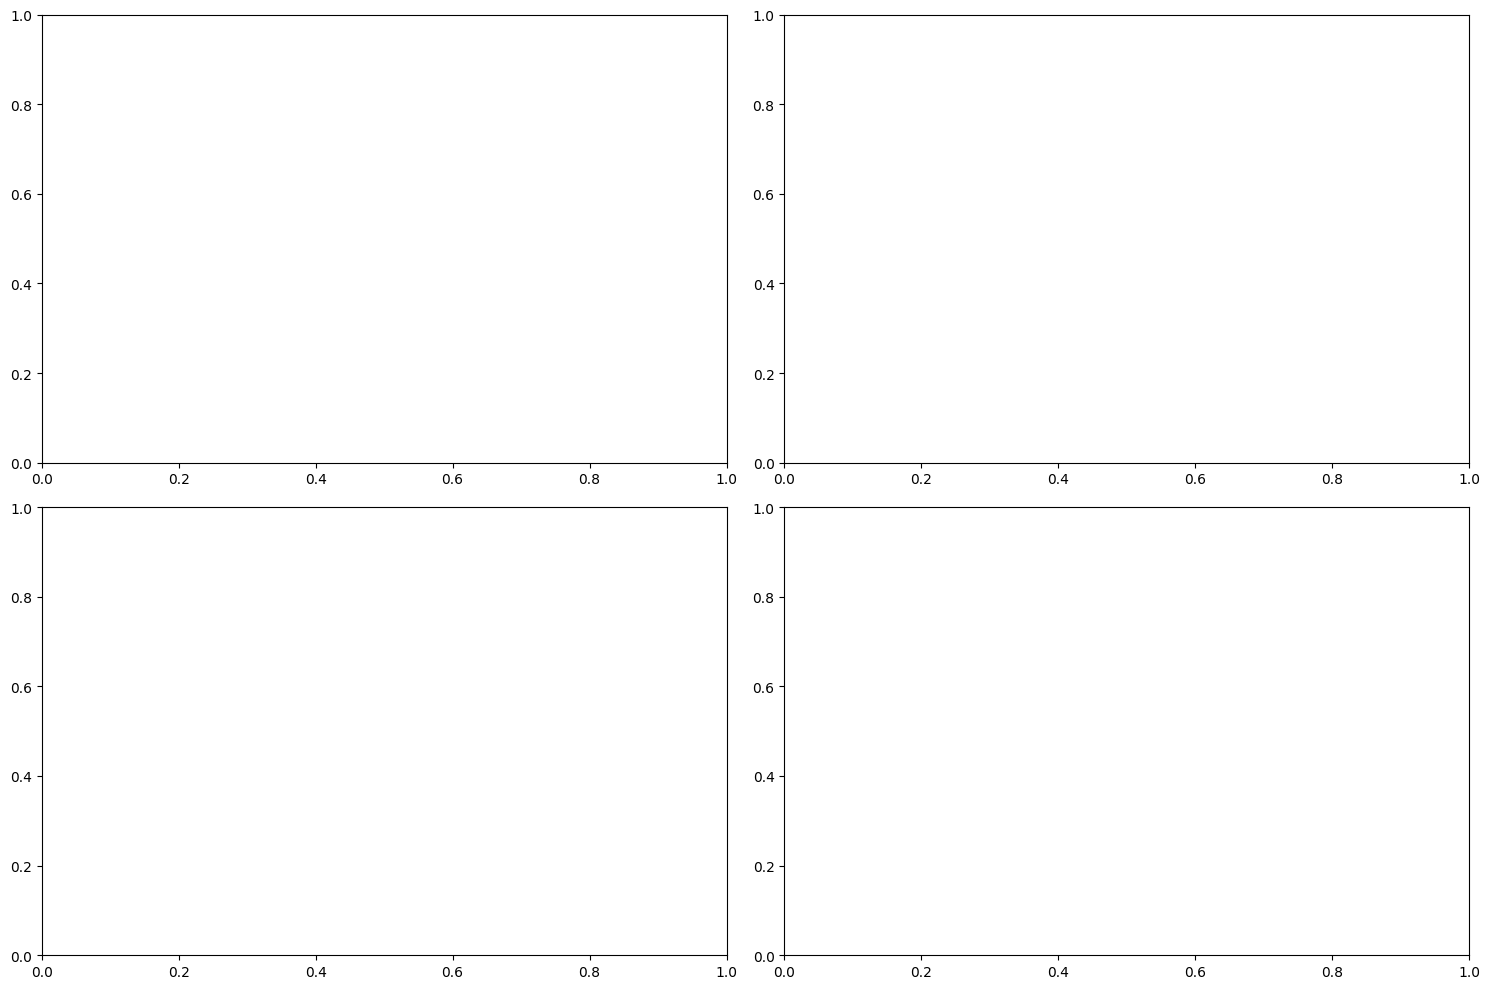

In [ ]:

# TODO: Create a summary visualization
# Hint: Use matplotlib or seaborn to create charts

import matplotlib.pyplot as plt
import pandas as pd

# Convert results to DataFrame for easier analysis
df = pd.DataFrame(analysis_results)

# TODO: Create visualizations
# 1. Sentiment scores by category
# 2. Most common emotional adjectives
# 3. Action verbs frequency

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# TODO: Plot 1 - Sentiment by category
# YOUR CODE HERE

# TODO: Plot 2 - Word frequency analysis
# YOUR CODE HERE

# TODO: Plot 3 - Problem categorization
# YOUR CODE HERE

# TODO: Plot 4 - Urgency analysis
# YOUR CODE HERE

plt.tight_layout()
plt.show()



### 💼 Business Impact Questions:
1. How could this analysis help prioritize customer service tickets?
**Ans:
This analysis help prioritize customer service tickets are:
- Sentiment Scores that quantify negative emotional adjective. For example, frustrated, unacceptable, and ridiculous are assign to higher priority to severely dissatisfied customers.
- Urgency Keywords: Identify specific time-sensitive indicators or adverbs. For example immediately and ASAP is automatically elevate queue placement.
- Action & Impact Verbs is flagging high risk actions such as cancelling or charged that triggers immediate retention routing or escalation.

2. What patterns do you notice in different problem categories?
**Ans:
Patterns I notice in different problem categories are:
- Account Access: Heavy concentration of negative emotional adjectives paired with duration-related terms such as hours and locked.
- Technical Issues is when the feature-specific nouns such as mobile app, and photos that are coupled with problem verbs (crashes)
- Billing is where strong negative sentiment mixed with high urgency keywords such as charged, refund, immediately, and canceling.
- User Guidance where lowering negative sentiment, higher density of inquiry verbs like walk through, find and interface nouns like features, interface.

3. How might you automate the routing of calls based on POS analysis?
**Ans:
Automate the routing of calls based on POS analysis
- Entity & Noun Extraction is when map specific problem nouns such as billing, app, and account directly to specialized department queues.
- Intent Identification via Action Verbs where the direct calls based on action verbs such as refund goes to Finance; and fix/upload goes to Tier 1 Tech Support.
- Dynamic Tier Escalate is where the route calls with high negative sentiment and urgent action verbs directly to high-tier support or supervisors.

4. What are the limitations of this approach?
**Ans:
The limitations of this approach are:
- Noise and Informal Speech is disfluencies such as um, like, slang, and informal contractions reduce tagging accuracy.
- Lack of Deep Context is when POS tags extract grammatical roles but miss broader semantic context or complex sarcasm.
- Vocabulary Ambiguity is when the context-dependent words can be mis-tagged, altering calculated sentiment or intent scores.


## ⚡ Lab Exercise 3: Tagger Performance Benchmarking (20 minutes)

Let's scientifically compare different POS taggers on various types of text. This will help you understand when to use which tool.


In [ ]:

import time
from collections import defaultdict

# Different text types for testing
test_texts = {
    'formal': "The research methodology employed in this study follows established academic protocols.",
    'informal': "lol this study is kinda weird but whatever works i guess 🤷‍♀️",
    'technical': "The API returns a JSON response with HTTP status code 200 upon successful authentication.",
    'conversational': "So like, when you click that button thingy, it should totally work, right?",
    'mixed': "OMG the algorithm's performance is absolutely terrible! The accuracy dropped to 23% wtf"
}

# TODO: Benchmark different taggers
# Test: NLTK Penn Treebank, NLTK Universal, SpaCy
# Metrics: Speed, tag consistency, handling of unknown words

benchmark_results = defaultdict(list)

for text_type, text in test_texts.items():
    print(f"\n🧪 Testing {text_type.upper()} text:")
    print(f"Text: {text}")
    print("-" * 60)

    # TODO: NLTK Penn Treebank timing
    start_time = time.time()
    nltk_penn_tokens = nltk.word_tokenize(text)
    nltk_penn_tags = nltk.pos_tag(nltk_penn_tokens)
    nltk_penn_time = time.time() - start_time

    # TODO: NLTK Universal timing
    start_time = time.time()
    nltk_univ_tokens = nltk.word_tokenize(text)
    nltk_univ_tags = nltk.pos_tag(nltk_univ_tokens, tagset='universal')
    nltk_univ_time = time.time() - start_time

    # TODO: SpaCy timing
    start_time = time.time()
    spacy_doc = nlp(text)
    spacy_time = time.time() - start_time

    # TODO: Count unknown/problematic tags
    # For NLTK, 'SYM' (Symbol) is a good indicator of problematic tokens.
    # For SpaCy, 'X' (Other) and 'SYM' (Symbol) are indicators.
    nltk_unknown = sum(1 for word, tag in nltk_penn_tags if tag == 'SYM')
    spacy_unknown = sum(1 for token in spacy_doc if token.pos_ == 'X' or token.pos_ == 'SYM')

    # Store results
    benchmark_results[text_type] = {
        'nltk_penn_time': nltk_penn_time,
        'nltk_univ_time': nltk_univ_time,
        'spacy_time': spacy_time,
        'nltk_unknown': nltk_unknown,
        'spacy_unknown': spacy_unknown
    }

    print(f"NLTK Penn time: {nltk_penn_time:.4f}s")
    print(f"NLTK Univ time: {nltk_univ_time:.4f}s")
    print(f"SpaCy time: {spacy_time:.4f}s")
    print(f"NLTK unknown words: {nltk_unknown}")
    print(f"SpaCy unknown words: {spacy_unknown}")

# TODO: Create performance comparison visualization
# This part will be addressed in a follow-up step if requested, as the primary goal is fixing the SyntaxError.



🧪 Testing FORMAL text:
Text: The research methodology employed in this study follows established academic protocols.
------------------------------------------------------------
NLTK Penn time: 0.0008s
NLTK Univ time: 0.0005s
SpaCy time: 0.0149s
NLTK unknown words: 0
SpaCy unknown words: 0

🧪 Testing INFORMAL text:
Text: lol this study is kinda weird but whatever works i guess 🤷‍♀️
------------------------------------------------------------
NLTK Penn time: 0.0010s
NLTK Univ time: 0.0007s
SpaCy time: 0.0082s
NLTK unknown words: 0
SpaCy unknown words: 0

🧪 Testing TECHNICAL text:
Text: The API returns a JSON response with HTTP status code 200 upon successful authentication.
------------------------------------------------------------
NLTK Penn time: 0.0008s
NLTK Univ time: 0.0006s
SpaCy time: 0.0091s
NLTK unknown words: 0
SpaCy unknown words: 0

🧪 Testing CONVERSATIONAL text:
Text: So like, when you click that button thingy, it should totally work, right?
------------------------------


### 📊 Performance Analysis:
1. Which tagger is fastest? Does speed matter for your use case?
**Ans:
The tagger that is the fastest is SpaCy. SpaCy is written in Cython and operates as an integrated single-pass pipeline, allowing it to process large batches of text rapidly.
Yes, speed matters for me in my case. If speed matters, the processing high-volume real-time data streams customer service call transcripts, social media monitoring, or large-scale web requires SpaCy’s high throughput to maintain low latency and avoid system bottlenecks. If speed doesn't matter, the small-scale offline analytics, academic experiments, or instructional environments will work well with NLTK, as overall processing time remains sub-second regardless of execution model.

2. Which handles informal text best?
**Ans:
The tagger that handles inmformal text best is SpaCy. The reason for this is because SpaCy tokenizer includes robust built-in exception handling for contractions such as modern slang and emojis. Its statistical neural/machine-learning tagger relies on broad context rather than rigid syntax, allowing it to predict reasonable grammatical tags for ungrammatical inputs. NLTK's default Punkt tokenizer and Averaged Perceptron Tagger tend to misclassify merged words, abbreviations, or missing punctuation, producing higher rates of unknown or misassigned tags.

3. How do the taggers compare on technical jargon?
**Ans:
The taggers compare on technical jargon is SpaCy performs stronger out-of-the-box on domain-specific technical terms because its models are trained on larger, more modern corpora. It uses word vectors and contextual representations that capture technical usage even for novel tokens.
Then NLTK struggles with modern technical jargon out-of-the-box, often defaulting to mistagging technical acronyms or terms as standard Nouns or Proper Nouns. However, NLTK allows full customization and manual rule building, making it easier to plug in custom regex patterns or lookup dictionaries if explicit control over domain jargon is needed.

4. What trade-offs do you see between speed and accuracy?
**Ans:
The trade-offs I see between speed and accuracy are
- NLTK that does trades processing speed and out-of-the-box accuracy for inspectability and algorithmic control. It provides granular access to every stage of tagging, making it valuable for research, educational exploration, or customized rule-based parsing.
- SpaCy that optimizes strictly for production efficiency and state-of-the-art performance. You trade manual step-by-step control for a fast, unified pipeline that yields higher accuracy across noisy, real-world data without additional configuration.


## 🚨 Lab Exercise 4: Edge Cases and Error Analysis (15 minutes)

Every system has limitations. Let's explore the edge cases where POS taggers struggle and understand why.


In [ ]:

# Challenging edge cases
edge_cases = [
    "Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.",  # Famous ambiguous sentence
    "Time flies like an arrow; fruit flies like a banana.",              # Classic ambiguity
    "The man the boat the river.",                                       # Garden path sentence
    "Police police Police police police police Police police.",          # Recursive structure
    "James while John had had had had had had had had had had had a better effect on the teacher.",  # Had had had...
    "Can can can can can can can can can can.",                         # Modal/noun ambiguity
    "@username #hashtag http://bit.ly/abc123 😂🔥💯",                   # Social media elements
    "COVID-19 AI/ML IoT APIs RESTful microservices",                    # Modern technical terms
]

print("🚨 EDGE CASE ANALYSIS")
print("=" * 50)

# TODO: Process each edge case and analyze failures
for i, text in enumerate(edge_cases, 1):
    print(f"\n🔍 Edge Case {i}:")
    print(f"Text: {text}")
    print("-" * 30)

    try:
        # TODO: Process with both taggers
        nltk_tokens = nltk.word_tokenize(text)
        nltk_tags = nltk.pos_tag(nltk_tokens)
        spacy_doc = nlp(text)

        # TODO: Identify potential errors or weird tags
        # Look for: repeated tags, unusual patterns, X tags, etc.

        print("NLTK tags:", [(w, t) for w, t in nltk_tags])
        print("SpaCy tags:", [(token.text, token.pos_) for token in spacy_doc])

        # TODO: Analyze what went wrong
        print("  Potential issues: (Manual inspection needed or specific error checks can be added here)")
        # Example of specific error checks:
        # For NLTK, check for 'SYM' tags
        # nltk_problem_tags = [(w, t) for w, t in nltk_tags if t == 'SYM']
        # if nltk_problem_tags: print(f"    NLTK problematic tags: {nltk_problem_tags}")

        # For SpaCy, check for 'X' (Other) or 'SYM' (Symbol) tags
        # spacy_problem_tokens = [(token.text, token.pos_) for token in spacy_doc if token.pos_ == 'X' or token.pos_ == 'SYM']
        # if spacy_problem_tokens: print(f"    SpaCy problematic tokens: {spacy_problem_tokens}")

    except Exception as e:
        print(f"❌ Error processing: {e}")

# TODO: Reflection on limitations
print("\n🤔 REFLECTION ON LIMITATIONS:")
print("=" * 40)
print("  After reviewing the output above, one can reflect on how each tagger handles extreme ambiguity, unconventional grammar, and new vocabulary/symbols.")
print("  SpaCy's tokenization often groups elements like emojis or hashtags differently than NLTK, which might influence tagging.")
print("  Sentences with high lexical ambiguity (like 'Buffalo buffalo...') often challenge rule-based and even statistical taggers to produce a coherent grammatical structure without deeper semantic understanding.")


🚨 EDGE CASE ANALYSIS

🔍 Edge Case 1:
Text: Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.
------------------------------
NLTK tags: [('Buffalo', 'NNP'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('.', '.')]
SpaCy tags: [('Buffalo', 'PROPN'), ('buffalo', 'NOUN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('.', 'PUNCT')]
  Potential issues: (Manual inspection needed or specific error checks can be added here)

🔍 Edge Case 2:
Text: Time flies like an arrow; fruit flies like a banana.
------------------------------
NLTK tags: [('Time', 'NNP'), ('flies', 'NNS'), ('like', 'IN'), ('an', 'DT'), ('arrow', 'NN'), (';', ':'), ('fruit', 'CC'), ('flies', 'NNS'), ('like', 'IN'), ('a', 'DT'), ('banana', 'NN'), ('.', '.')]
SpaCy tags: [('Time', 'NOUN'), ('flies', 'VERB'), ('like', 'ADP'), ('an', 'DET'), 


### 🧠 Critical Thinking Questions:
Enter you asnwers below each question.
1. Why do these edge cases break the taggers?
**Ans:
These edges cases break the taggers because it relies heavily on local n-gram contexts, morphological rules and fixed dictionary probabilities.
Here are three edge cases break the taggers are:
- Lexical Ambiguity & Homonyms is when repeating identical words such as "Can can can..." or homonym clusters such as "Buffalo buffalo..." break local transition probabilities in Hidden Markov Models (HMMs) or Conditional Random Fields (CRFs).
- Garden Path Sentences is when the sentences like "The man the boat" trick greedy, left-to-right parsers because "man" functions as a verb, but taggers commit to its higher-frequency noun form early.
- Out-of-Vocabulary (OOV) Terms where slang ("fr fr"), modern jargon ("RESTful"), and noisy social media elements (hashtags, emojis) lack explicit entry in static training corpora, forcing taggers to guess tags based on fallback rules.

2. How might you preprocess text to handle some of these issues?
**Ans:
To preprocess text to handle some of these issues are:
- Text Normalization where using lowercase text, standardize contractions and remove or map emojis/hashtags to unified placeholder tokens.
- Spell & Slang Correction is when running a dictionary-based or edit-distance lookup to map informal expressions such as "rn" and "smh" to standard language before tokenization.
- Custom Regex & Tokenization Rules is to intercept complex domain terms such as "COVID-19", and "AI/ML" using custom regex boundaries to prevent sentence splitters from breaking hyphenated/slashed jargon.

3. When would these limitations matter in real applications?
**Ans:
These limitations matter in real application is:
-Search Engines & IR which is misclassifying a key noun such as "apple" company vs. "apple" fruit as a verb breaks query understanding and returns irrelevant results.
- Customer Support Automation is errors tagging emotion-bearing adjectives or action verbs cause automated ticket-routing systems to miss urgent or dissatisfied customers.
- Text-to-Speech (TTS) is when the incorrect POS tagging leads to wrong phonetic pronunciations such as pronouncing "lead" as /lɛd/ instead of /liːd/.

4. How do modern large language models handle these cases differently?
**Ans:
Modern large language models handle these cases differently is:
- Global Bidirectional Attention where the transformer-based LLMs process the entire sequence simultaneously using self-attention rather than relying on left-to-right greedy windows.
- Subword Tokenization is when the Byte-Pair Encoding (BPE) breaks OOV jargon into sub-morphemes, allowing models to infer grammatical rules for unseen words.
- Deep Contextual Embeddings is when the LLMs resolve structural ambiguity (like garden path sentences) by evaluating deep semantic relationships across the whole document.
---



## 🎯 Final Reflection and Submission

Congratulations! You've completed a comprehensive exploration of POS tagging, from basic concepts to real-world challenges.

### 📝 Reflection Questions (Answer in the cell below):

1. **Tool Comparison**: Based on your experience, when would you choose NLTK vs SpaCy? Consider factors like ease of use, accuracy, speed, and application type.

2. **Real-World Applications**: Describe a specific business problem where POS tagging would be valuable. How would you implement it?

3. **Limitations and Solutions**: What are the biggest limitations you discovered? How might you work around them?

4. **Future Learning**: What aspects of POS tagging would you like to explore further? (Neural approaches, custom training, domain adaptation, etc.)

5. **Integration**: How does POS tagging fit into larger NLP pipelines? What other NLP tasks might benefit from POS information?



### ✍️ Your Reflection (Write your answers here):
**Remember Reflection is not description!**

**1. Tool Comparison:**
**Ans: I would choose SpaCy. The reason I choose this are
- Ease of Use: SpaCy is significantly easier for production integration because it provides out-of-the-box pipeline models that output clean tokens, lemmas, and tags in a single call. NLTK requires manually combining separate tokenizers and taggers and managing dataset downloads.
- Accuracy: SpaCy delivers higher out-of-the-box accuracy on real-world text because its models rely on transition-based neural network architectures trained on contextual windows. NLTK's default statistical taggers rely heavily on standard, formal corpora like the Penn Treebank and degrade on uncleaned text.
-Speed: SpaCy is optimized in Cython for high-throughput batch processing, executing tokenization and POS tagging considerably faster than NLTK’s pure-Python implementation.
- Application Type: Choose NLTK for research, teaching linguistic fundamentals, or custom algorithm prototyping. Choose SpaCy for production applications, microservices, fast APIs, and scalable end-to-end NLP pipelines.

**2. Real-World Applications:**
**Ans:
A specific business problem where POS tagging would be valuable is an Automated Urgent Ticket Routing & Aspect-Based Sentiment Analysis for Customer Support.
To implement it is:
- Filtering & Extraction: Extract target nouns for entities/features like "billing", "login", "app" and using NN / NOUN tags.
- Sentiment Modifier Identification: Extract nearby adjectives (JJ / ADJ) connected via dependency parsing such as "broken", "unacceptable", "slow".
- Action Identification: Extract action-oriented verbs such as VB / VERB, "cancel", "refund", and "fix".
- Routing Engine: Pass these extracted structural features into a rule-based or machine learning classifier to instantly route "cancellation" or "billing error" tickets directly to tier-3 human agents while ignoring conversational filler words.

**3. Limitations and Solutions:**
**Ans:
The biggest limitations I discovered are Out-of-Vocabulary (OOV) & Slang and Contextual Ambiguity (Heteronyms).
Out-of-Vocabulary (OOV) & Slang is when Off-the-shelf models struggle with domain jargon, emojis, typos, or rapid internet slang. To resolve this is implementing pre-tagging text normalization pipelines such as regex spell-fix, emoji conversion, slang mapping or fine-tune tagger embeddings on domain-specific text.   
Contextual Ambiguity (Heteronyms) is when words whose part of speech changes completely based on sentence structure such as "object" as noun vs. verb. To resolve this is utilizing transformer-based embeddings (ike BERT or SpaCy-Transformers that generate contextualized token representations rather than static lookups.

**4. Future Learning:**
**Ans:
The aspects of POS tagging that I would like to explore further are Transformer-Based Tagging, Domain Adaptation & Custom Training and Multilingual POS Tagging.
The reason for this is
- Transformer-Based Tagging is studying how self-attention mechanisms in transformer architectures capture long-range sentence dependencies compared to traditional sequence taggers such as HMMs, CRFs, or LSTMs.
- Domain Adaptation & Custom Training is fine-tuning pre-trained POS taggers on specialized datasets such as medical clinical notes, legal contracts, or social media transcripts to reduce OOV rates.
- Multilingual POS Tagging is exploring cross-lingual transfer learning to project POS tags from resource-rich languages to low-resource languages using Universal Dependencies.

**5. Integration:**
**Ans:
POS tagging fit into larger NLP pipelines is served as a foundational upstream feature in NLP architecture.
Other NLP tasks might benefit from POS information are:
- Named Entity Recognition (NER) is where POS tags help NER models identify proper noun boundaries (NNP) and distinguish people/places from common verbs or adjectives.
- Lemmatization is where accurate lemmatization requires the POS tag as input such as converting "meeting" to verb "meet" vs. leaving it as noun "meeting".
- Syntactic Dependency Parsing is when POS tags act as primary constraints for sentence structure trees and grammatical relation mapping.
-  Text-to-Speech (TTS) Synthesis is when the TTS engines use POS tags to resolve pronunciation rules for heteronyms. For example pronouncing "read" in past vs. present tense.



---

## 📤 Submission Checklist

Before submitting your completed notebook, make sure you have:

- [ ] ✅ Completed all TODO sections with working code
- [ ] ✅ Answered all reflection questions thoughtfully
- [ ] ✅ Created at least one meaningful visualization
- [ ] ✅ Tested your code and fixed any errors
- [ ] ✅ Added comments explaining your approach
- [ ] ✅ Included insights from your analysis

### 📋 Submission Instructions:
1. **Save your notebook**: File → Save (or Ctrl+S)
2. **Download**: File → Download → Download .ipynb
3. **Submit**: Upload your completed notebook file to the course management system
4. **Filename**: Use format: `L05_LastName_FirstName_ITAI2373.ipynb or pdf`  

### 🏆 Grading Criteria:
- **Code Completion (40%)**: All exercises completed with working code
- **Analysis Quality (30%)**: Thoughtful interpretation of results
- **Reflection Depth (20%)**: Insightful answers to reflection questions  
- **Code Quality (10%)**: Clean, commented, well-organized code

---

## 🎉 Great Work!

You've successfully explored the fascinating world of POS tagging! You now understand how computers parse human language and can apply these techniques to solve real-world problems.


Keep exploring and happy coding! 🚀
